In [ ]:
> Continúa `REPORTE_ACTUALIZACION_V2_2.md`. Entorno: conda `master_air_quality`. **Sin GPU.**
> Este ciclo absorbe además las Fases 4, 5 y 7 del prompt final, que estaban en espera.

---

## Decisión tomada

**El modelo final del manuscrito pasa a ser `agat_wavenet_evtA2` (pérdida EVT de tres regímenes), ensamble de 6 semillas, punto de control `best_f1`.** Es lo que dicta la regla literal de §2.7.3 y gana también en MAE de validación, así que no hay intercambio que ponderar. La diferencia frente a `evtA1` no es distinguible de cero y eso se dirá en el manuscrito; no se añade ninguna cláusula de desempate.

**Ensamble = 6 semillas {1, 2, 7, 13, 23, 42} en todas las configuraciones.**

**Regla de oro sin cambios:** cada número procede de un artefacto en disco, citado por ruta. Si algo no existe, detente y anótalo en `DISCREPANCIAS / FALTANTES`.

---

## BLOQUE 1 — Todo lo que se hace sin tocar test

### 6D.0 — Fijar el clamp y verificar consistencia retroactiva (**bloqueante, hazlo primero**)

Se adopta **recortar por semilla y después promediar**, con el techo en el **máximo observado del panel = 1001.0 µg/m³**.

Esto no es cosmético para `evtA2`: la semilla 7 tiene techo 2 160 con 372 predicciones sobre 1 000, y la 13 tiene 1 más. El orden del clamp **cambia el ensamble**.

1. Verifica con qué orden se calcularon las cifras de la Fase 6C que decidieron el modelo final (`evtA2` ENS6: MAE 20.740, F1 0.3762; `evtA1` ENS6: 21.001, 0.3630). Si se usó promediar→recortar, **recalcula ambas con el orden adoptado y confirma que el ganador no cambia.** Si cambia, detente y avísame de inmediato.
2. Recalcula con el orden y el techo adoptados todas las cifras ya emitidas en el reporte para las 6 configuraciones, en validación y las de test ya producidas. Reporta qué valores se movieron y en qué decimal.
3. Deja constancia del criterio en una sola línea reutilizable por todos los scripts posteriores, para que no vuelva a haber dos órdenes en circulación.

### 6D.1 — Mecanismo: ¿por qué `evtA2` es más estable que `evtA1`?

Hipótesis a probar: la estratificación mensual (12 estratos) ajusta los parámetros de cola con una cuarta parte de los datos por estrato frente a la de tres regímenes, y esa estimación más ruidosa es lo que se descompone en ciertas semillas.

Solo con train y validación:

1. **Conteo de excedencias por estrato** en train bajo cada esquema: número de observaciones sobre el umbral de cola por mes (A1) y por régimen (A2), por cúmulo espacial, con mínimo, mediana y máximo por estrato.
2. **Parámetros de cola ajustados** por estrato bajo cada esquema, con su dispersión.
3. **Cruce con la inestabilidad:** para las semillas de `evtA1` que produjeron predicciones sobre 1 000 (13, 23, 42), identifica **en qué estratos y en qué meses** se concentran esas predicciones. Si caen preferentemente en los estratos con menos excedencias, la hipótesis queda respaldada.

Reporta el resultado sea cual sea. Si la hipótesis no se sostiene, dilo: el manuscrito se limitará a reportar la inestabilidad sin explicarla.

### 6D.2 — Ablación A reanclada (parte de validación)

La comparación de arquitecturas se reancla en **`gnn_lstm_evtA2` frente a `agat_wavenet_evtA2`**, con corroboración cruzada bajo las otras dos pérdidas. Prepara en validación, 6 semillas, con clamp: MAE y F1 por semilla (media ± sd) y del ensamble, para las 6 configuraciones. Las métricas de test salen en el Bloque 2.

Reporta además el **cociente de desviaciones estándar entre arquitecturas bajo A2, con su IC95 por bootstrap sobre semillas**, para dejar por escrito —igual que en 6A.2— que la cantidad no es afirmable, ahora con n = 6.

### 6D.3 — Recalibrar R0 sobre `evtA2` (solo validación)

Los umbrales τ = 96 y 84 se calibraron sobre predicciones de `evtA1` y **quedan invalidados**. Repite el procedimiento **idéntico en método** sobre el ensamble de 6 semillas de `evtA2`:

1. τ por temporada (nov–abr y may–oct) que **maximiza F2@132 en validación 2024**, sobre rejilla τ ∈ [60, 200] paso 1.
2. Confirma o refuta, como en el ciclo anterior, que los esquemas alternativos —votación entre semillas y umbral sobre media más múltiplo de la dispersión— siguen siendo inferiores al umbral simple por temporada.
3. Regla de equilibrio: τ que **maximiza POD sujeto a no exceder la FAR del modelo sin EVT**. El ciclo anterior no la produjo bajo v2.2 y falta en `tab:alerta`. Calíbrala ahora en validación; si no es calculable, dilo y proponme si la fila se retira de la tabla.
4. **No recalibres R1.** Fue rechazada por el control aleatorio y entra al manuscrito como resultado negativo, no como regla candidata. Sí hay que **recalcular su rechazo sobre `evtA2`** (ΔF2 frente al p95 del control con bins aleatorios de la misma cardinalidad), porque el número actual se obtuvo con A1.

### 6D.4 — Congelamiento **físicamente separado** (esto se hizo mal la vez pasada)

Escribe `config_v3_v2_2_A2.yaml` desde un **script propio, independiente del que evalúa test**, en una ejecución propia y con **commit propio**. Registra el hash del commit y la marca de tiempo del archivo en el reporte. El script de test debe **leer** ese archivo, nunca escribirlo.

Contenido a congelar: modelo y semillas del ensamble, orden y valor del clamp, τ de R0 por temporada, τ de la regla de equilibrio, definición de episodio y ventana de captura, y los umbrales y cortes de R1 con su marca de rechazo.

**Detente aquí y muéstrame el archivo congelado y el hash antes de pasar al Bloque 2.**

---

## BLOQUE 2 — Pasada única sobre test (será la número 13)

**Un solo script, una sola ejecución, que produzca todo lo de abajo.** Enumera primero lo que va a calcular, ejecútalo una vez y no vuelvas a abrir test en este ciclo.

1. **`tab:global`** — tres filas (EVT tres regímenes como final, sin EVT, persistencia) sobre el universo completo de **3 019 344**: MAE, RMSE, R², MBE, sMAPE, POD, FAR, CSI, F1, F2. La fila de persistencia debe salir idéntica a la ya verificada (22.948 · 41.981 · −0.188); si no, es un error.
2. **`tab:ablacionA`** reanclada en A2, ensamble y media ± sd por semilla.
3. **`tab:ablacionB`** — tres pérdidas, con la de tres regímenes como final, incluida `MAE_MM` (banda 132–213) y **CSI de las tres filas**, que faltaba.
4. **Desgloses de §3.4** del modelo final: por horizonte (con persistencia), por hora local (MAE, RMSE, MBE), por mes y por estación (MAE con POD).
5. **`tab:bandas`** — cinco bandas con n, MAE, MBE y fracción. Los `n` dependen de la observación: si cambian respecto a los verificados, es error.
6. **`tab:alerta`** — cuatro filas sobre el universo completo: alta sensibilidad (R0 recalibrada), umbral fijo 132, equilibrio y referencia sin EVT. POD, FAR, CSI, F1, F2 y volumen de alarmas.
7. **Episodios** — sobre **todos** los episodios de test bajo la definición del paper, no solo los clasificables. Reporta el conteo total real (el manuscrito dice 489; el ciclo anterior evaluó 421 por restringirse a los clasificados) y la captura por regla, con desglose por temporada y por clase. Incluye **lead time** si el artefacto lo permite.
8. **Rechazo de R1** recalculado sobre A2: ΔF2 frente al p95 del control aleatorio.
9. **Horizonte estratificado por régimen** sobre A2, test: separación de medianas con IC95 por bootstrap de bloques de día, MAE, MBE y techo por horizonte, para estancamiento y advectivo. Y `h*_magnitud` por clase.
10. **Contraste entre clases** sobre A2: MBE y techo de pronóstico en h+1 por clase.
11. **Techo efectivo del ensamble final**, para la línea horizontal de `fig06`.

---

## BLOQUE 3 — Empaquetado

### 6D.5 — Inventario de sustituciones completo

Cierra el inventario con el formato de siempre (ID · ubicación · valor v2 · valor v2.2 · artefacto · ¿cambia la lectura?), ahora con `evtA2` como final, cubriendo G-01 a G-07, A-01 a A-04, B-01 a B-04, D-01 a D-05 y C-01 a C-06. **Marca en negrita toda fila `SÍ` y reporta el total.**

Recalcula los porcentajes de la Ablación B con A2 como final. Mis cifras provisionales, para que las contrastes: POD **+55 %**, F2 **+38 %**, ΔMAE **+1.99**, ΔRMSE **+2.56**, ΔFAR **+0.201**, MAE_MM **−7.23**. Si no coinciden, manda las tuyas y la razón.

Comprobaciones que hay que declarar: ¿el intercambio conserva forma y signo con A2 como final? ¿R0 sigue más que duplicando la POD frente al umbral fijo de 132? ¿Sigue capturando ≈99 % de los episodios sobre el total real? ¿La regla de equilibrio sigue dominada por el modelo sin EVT?

### 6D.6 — Figuras

Regenera las seis sobre el modelo final, mismo estilo y nombres, bilingües ES/EN, en PDF y JPEG: `fig01_error_por_horizonte`, `fig02b_error_por_hora_mbe`, `fig03b_error_por_estacion_pod`, `fig04_series_episodio`, `fig05_calibracion_alerta`, `fig06_dispersion_extremos`.

En `fig04`, verifica que el episodio del 19–31 de enero de 2025 sigue siendo el más representativo; si no, propón sustituto con justificación y no lo cambies sin avisarme.

### 6D.7 — Paquete para §3.6 y §4.4

Tablas listas para LaTeX, **sin redactar texto**: horizonte estratificado por régimen (test y validación, sin POD/FAR/F1); contraste entre clases; argumento físico (62.7 km, 4.19 m/s y 4.15 h en la clase advectiva, y 4.97 / 3.50 restringido a PM₁₀ ≥ 250, con la nota de que el agregado de 1.44 m/s está dominado por el estancamiento); nota de potencia de la clase advectiva; y el rechazo de R1 con su control, junto al diagnóstico de que `S(t)` no persiste 24 h por mérito propio.

### 6D.8 — Actualizar `IMPACTO EN LA SECCIÓN 2`

Añade a los seis puntos ya redactados:

7. **§2.6** — el modelo final es ahora la variante de tres regímenes; verifica que la descripción de la pérdida en §2.6 cubra ambas variantes sin necesidad de reescribirse, y señala cualquier frase que dé por sentado que la final es la mensual.
8. **§2.8** — el orden del clamp (recortar por semilla, después promediar) y el techo en 1001.0 justificado por el máximo observado.
9. **§2.7** — ensamble de 6 semillas en todas las configuraciones, y la evidencia de la Fase 6B de que las predicciones fuera del rango físico se concentran en las variantes con pérdida EVT y dependen de la semilla.
10. **§2.9** — el congelamiento de la Fase 6D.4, ahora sí con paso separado, con su hash de commit.

---

## Entrega

Actualiza `REPORTE_ACTUALIZACION_V2_2.md` conservando el formato. Cierra con:

- **`RESUMEN EJECUTIVO`** actualizado, respondiendo a las cuatro preguntas con `evtA2` como final.
- **`DISCREPANCIAS / FALTANTES`**, incluida la entrada 13 del registro de evaluaciones sobre test.

**Si en 6D.0 el ganador cambia al recalcular con el orden del clamp adoptado, detente antes de cualquier otra cosa y avísame.**

# 03 · Consultas — manual de uso

Cómo pedir cualquier serie climática de cualquier zona urbana de Tamaulipas.

> **Este notebook es autocontenido.** Corre de arriba a abajo sin necesitar los
> otros. La primera celda es el único requisito.

## El orden de trabajo

```
1. Mirar el catálogo        Q.catalogo()          ¿qué existe y cómo se llama?
2. Elegir la unidad         Q.resolver("victoria") o ambito="cabeceras"
3. Elegir las variables     V.CATALOGO            ¿temperatura? ¿GHI? ¿viento?
4. Acotar el periodo        desde= / hasta=       en hora LOCAL, inclusivos
5. Elegir la frecuencia     "hora" o "dia"
6. Pedir                    Q.serie(...)
```

Todo pasa por **una sola función**:

```python
Q.serie(variables, ciudad=None, ambito="localidades",
        desde=None, hasta=None, frecuencia="hora", ponderar=True)
```

## Requisitos

1. Los CSV de pesos: `python -m urbano.construir`
2. Los parquet anuales en `Data/Tamaulipas/<año>/Finales/completo/`

In [1]:
# --- arranque (correr siempre primero) ---------------------------------------
# Localiza la raíz del proyecto subiendo por el árbol de directorios, para que el
# notebook funcione sin importar desde dónde se lance Jupyter.
#
# La trampa: ESTA carpeta se llama `notebooks/urbano`. Buscar un directorio
# llamado "urbano" la encuentra a ella, y Python la importa como paquete de
# espacio de nombres vacío -> "cannot import name 'config' from 'urbano'
# (unknown location)". Por eso se exige el `__init__.py`: solo el paquete real
# lo tiene.
import os, sys


def _raiz_del_proyecto(inicio="."):
    d = os.path.abspath(inicio)
    while not os.path.isfile(os.path.join(d, "urbano", "__init__.py")):
        padre = os.path.dirname(d)
        if padre == d:
            raise RuntimeError(
                f"No encuentro el paquete `urbano` subiendo desde "
                f"{os.path.abspath(inicio)}. Abre Jupyter dentro del repo.")
        d = padre
    return d


RAIZ = _raiz_del_proyecto()
if RAIZ not in sys.path:
    sys.path.insert(0, RAIZ)

# Si una celda anterior ya importó el `urbano` equivocado, quedó cacheado y el
# arreglo del path no bastaría: hay que descartarlo para no exigir reiniciar el
# kernel.
for _m in [m for m in list(sys.modules) if m == "urbano" or m.startswith("urbano.")]:
    del sys.modules[_m]

import urbano
print("raíz del proyecto:", RAIZ)
print("paquete urbano   :", os.path.dirname(urbano.__file__))

# El paquete `urbano` se edita mientras el notebook está abierto, y Python NO
# recarga un módulo ya importado: la celda seguiría usando la versión vieja y
# fallaría con errores del tipo "['cve_mun'] not in index". `autoreload` vuelve
# a leer el código en cada ejecución de celda.
# (Si algo se comporta de forma rara igualmente, reinicia el kernel: autoreload
#  no rehace objetos que ya estén creados en memoria.)
%load_ext autoreload
%autoreload 2

import pandas as pd
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 50)

raíz del proyecto: /Users/esteban/Documents/ACADEMICO/DSI/Radiacion_Solar
paquete urbano   : /Users/esteban/Documents/ACADEMICO/DSI/Radiacion_Solar/urbano


In [2]:
from urbano import config as C
from urbano.clima import consulta as Q
from urbano.clima import variables as V

---
## Paso 1 · El catálogo: ¿qué puedo pedir?

`Q.catalogo()` es la tabla de todo lo consultable: 63 localidades urbanas, con su
clave, nombre, municipio, tipo y cobertura.

In [ ]:
cat = Q.catalogo()
print(f"{len(cat)} localidades urbanas consultables")
cat.head(12)

In [ ]:
# Cuántas hay de cada tipo.
cat["tipo"].value_counts().rename("localidades").to_frame()

In [ ]:
# Buscar en el catálogo, que muchas veces es todo lo que hace falta.
cat[cat["municipio"].str.contains("Altamira")]

In [ ]:
# Solo las que soportan una comparación seria (cobertura alta o media).
cat[cat["calidad"] != "baja"][
    ["cvegeo", "ciudad", "municipio", "tipo", "area_km2", "n_nodos", "calidad"]]

---
## Paso 2 · Elegir la unidad

Hay **dos formas excluyentes** de decir qué quieres:

| | parámetro | ejemplo |
|---|---|---|
| **una o varias localidades concretas** | `ciudad=` | `ciudad="victoria"` |
| **un conjunto entero** | `ambito=` | `ambito="cabeceras"` |

Si pasas `ciudad`, manda sobre `ambito`.

### 2a · Por nombre o clave — `resolver()`

Prueba, del más específico al más laxo:

1. clave `cvegeo` exacta → `"280410001"`
2. nombre exacto de la **localidad** → `"Ciudad Victoria"`
3. nombre exacto del **municipio** → `"Victoria"` (devuelve su cabecera)
4. coincidencia parcial única → `"matamoros"`

El paso 3 existe porque uno piensa en el municipio: `"victoria"` es ambiguo como
texto —existe también *Guadalupe Victoria*, en Abasolo— pero único como nombre de
municipio, y su cabecera es lo que se quería.

In [ ]:
for ref in ["280410001", "Ciudad Victoria", "ciudad victoria", "VICTORIA",
            "victoria", "matamoros", "miramar", "san nicolas", "tula"]:
    print(f"{ref!r:>18} -> {Q.resolver(ref, cat)}  "
          f"{cat.set_index('cvegeo').loc[Q.resolver(ref, cat), 'ciudad']}")

In [ ]:
# Un nombre ambiguo NO adivina: enumera los candidatos.
try:
    Q.resolver("ciudad", cat)
except ValueError as e:
    print(str(e)[:320], "…")

In [ ]:
# Un nombre inexistente manda al catálogo.
try:
    Q.resolver("Guadalajara", cat)
except ValueError as e:
    print(e)

### 2b · Por ámbito

| ámbito | unidades | qué es |
|---|---|---|
| `"cabeceras"` | 43 | las cabeceras municipales |
| `"otras"` | 20 | localidades urbanas que **no** son cabecera |
| `"localidades"` | 63 | todas (valor por omisión) |
| `"conglomerados"` | 55 | manchas conurbadas agrupadas |
| `"global"` | 1 | todo lo urbano del estado como una sola serie |

In [ ]:
for a in Q.AMBITOS:
    w = Q.pesos(a)
    print(f"{a:15s} {w['cvegeo'].nunique():3d} unidades · "
          f"{w['nodo_id'].nunique():3d} nodos")

In [ ]:
# Los conglomerados con más de una localidad.
w = Q.pesos("conglomerados")
tam = w[w["ciudad"] == "Tampico"]
print(f"El conglomerado de Tampico agrupa {len(tam)} nodos")
tam.head()

---
## Paso 3 · Elegir las variables

Cualquier subconjunto del catálogo de `urbano.clima.variables`. Por omisión se
usan 10 (`V.POR_OMISION`), pero las 25 están disponibles pidiéndolas por nombre.

Recuerda: `temperature` y `wind_speed` son a **2 m** (ver notebook 02);
`cloud_type` y `cloud_fill_flag` son códigos y se **rechazan** con error.

In [ ]:
print("Por omisión:", V.POR_OMISION)
print("\nTodas las disponibles:")
V.tabla()[["variable", "unidad", "altura", "tipo"]]

---
## Paso 4 · Acotar el periodo

`desde` y `hasta` son **inclusivos** y en **hora local**. Aceptan cualquier cosa
que entienda `pd.Timestamp`: `"2024-06-01"`, un `date`, un `Timestamp`. `None` =
sin límite.

Solo se abren los años necesarios — más el siguiente al del final, porque las
últimas horas del 31 de diciembre local viven en el archivo del año siguiente
(local = UTC−6). Sin eso, ese día saldría con 18 h en lugar de 24.

In [ ]:
print("2024-06-01 → 2024-06-30 abre:", Q._anios("2024-06-01", "2024-06-30"))
print("2023-01-01 → 2023-12-31 abre:", Q._anios("2023-01-01", "2023-12-31"))
print("sin límites          abre:", Q._anios(None, None))

---
## Paso 5 · La frecuencia

| `frecuencia` | qué devuelve | filas |
|---|---|---|
| `"hora"` (por omisión) | la serie horaria: una fila por (unidad, hora) | 24 por día |
| `"dia"` | media / mínimo / máximo por día local + `n_horas` | 1 por día |

**No hay `"mes"` a propósito.** Un "mínimo mensual" es ambiguo: ¿el mínimo
absoluto del mes, o la media de los mínimos diarios? Son cosas distintas y la
respuesta depende de para qué. En el recetario (paso 7) está cómo hacer cada una
con una línea de pandas.

In [ ]:
# Horaria.
Q.serie(["temperature"], ciudad="victoria",
        desde="2024-06-01", hasta="2024-06-02").head()

In [ ]:
# Diaria: media, mínimo y máximo. Esto es lo que se suele querer.
Q.serie(["temperature"], ciudad="victoria",
        desde="2024-06-01", hasta="2024-06-30", frecuencia="dia").head()

---
## Paso 6 · Las variantes, una por una

### 6a · Una ciudad, una variable, un rango — el caso típico

In [ ]:
Q.serie(["temperature"], ciudad="victoria",
        desde="2024-06-01", hasta="2024-06-30", frecuencia="dia").head()

### 6b · Por clave INEGI en vez de por nombre

In [ ]:
Q.serie(["temperature"], ciudad="280410001",
        desde="2024-06-01", hasta="2024-06-03").head()

### 6c · Varias variables a la vez

In [ ]:
Q.serie(["temperature", "relative_humidity", "wind_speed", "ghi"],
        ciudad="victoria", desde="2024-06-01", hasta="2024-06-30",
        frecuencia="dia").head()

### 6d · Varias ciudades a la vez

In [ ]:
(Q.serie(["temperature"], ciudad=["victoria", "tampico", "reynosa"],
         desde="2024-07-01", hasta="2024-07-31", frecuencia="dia")
   .groupby("ciudad")[["temperature_media", "temperature_min", "temperature_max"]]
   .agg(["mean", "min", "max"]).round(1))

### 6e · Todas las localidades urbanas de un municipio

`ciudad="altamira"` devuelve solo la **cabecera**. Para las tres localidades
urbanas del municipio hay que sacarlas del catálogo y pasarlas como lista.

In [ ]:
claves_alt = cat.loc[cat["municipio"] == "Altamira", "cvegeo"].tolist()
print("localidades urbanas del municipio de Altamira:", claves_alt)

(Q.serie(["temperature"], ciudad=claves_alt,
         desde="2024-07-01", hasta="2024-07-31", frecuencia="dia")
   .groupby("ciudad")["temperature_media"].agg(["count", "mean"]).round(2))

### 6f · Un ámbito completo

In [ ]:
# Las 43 cabeceras, un mes, resumen diario.
cab = Q.serie(["temperature"], ambito="cabeceras",
              desde="2024-07-01", hasta="2024-07-31", frecuencia="dia")
print(cab.shape, "·", cab["ciudad"].nunique(), "cabeceras")
cab.groupby("ciudad")["temperature_media"].mean().sort_values(
    ascending=False).head(8).round(2)

In [ ]:
# Conglomerados urbanos.
(Q.serie(["temperature"], ambito="conglomerados",
         desde="2024-07-01", hasta="2024-07-31", frecuencia="dia")
   .groupby("ciudad")["temperature_media"].mean()
   .sort_values(ascending=False).head(5).round(2))

In [ ]:
# El estado urbano entero como una sola serie.
Q.serie(["temperature", "ghi"], ambito="global",
        desde="2024-01-01", hasta="2024-12-31", frecuencia="dia").head()

### 6g · Promedio simple en vez de ponderado

`ponderar=False`: todos los nodos de la unidad cuentan igual (ver notebook 02).

In [ ]:
a = Q.serie(["temperature"], ciudad="san fernando",
            desde="2024-07-01", hasta="2024-07-31", frecuencia="dia")
b = Q.serie(["temperature"], ciudad="san fernando",
            desde="2024-07-01", hasta="2024-07-31", frecuencia="dia",
            ponderar=False)
pd.DataFrame({"ponderado": a["temperature_media"].to_numpy(),
              "simple": b["temperature_media"].to_numpy()}).describe().round(3)

---
## Paso 7 · Recetario

### 7a · Agregación mensual

No es una `frecuencia` porque hay que decidir qué significa. Las tres lecturas
razonables, cada una con su línea:

In [ ]:
d = Q.serie(["temperature"], ciudad="victoria",
            desde="2024-01-01", hasta="2024-12-31", frecuencia="dia")
d["mes"] = pd.to_datetime(d["fecha_local"]).dt.to_period("M")

pd.DataFrame({
    # media de las medias diarias: la temperatura "típica" del mes
    "media_mensual": d.groupby("mes")["temperature_media"].mean(),
    # media de los máximos diarios: el "calor de la tarde" típico
    "max_diario_medio": d.groupby("mes")["temperature_max"].mean(),
    # máximo absoluto del mes: el récord
    "max_absoluto": d.groupby("mes")["temperature_max"].max(),
    "min_absoluto": d.groupby("mes")["temperature_min"].min(),
}).round(2)

### 7b · Solo horas de sol

Para métricas de irradiancia sin diluirlas con la noche.

In [ ]:
h = Q.serie(["ghi"], ciudad=["victoria", "tampico"],
            desde="2024-01-01", hasta="2024-12-31")
dia = h[h["ghi"] > 0]
n_dias = h.groupby("ciudad")["fecha_local"].nunique()
(dia.groupby("ciudad")["ghi"]
    .agg(horas_luz="size", ghi_medio_diurno="mean")
    .assign(horas_luz_por_dia=lambda x: x["horas_luz"] / n_dias)
    [["horas_luz_por_dia", "ghi_medio_diurno"]].round(1))

### 7c · Comparar ciudades hora a hora

Cruza siempre por `datetime_utc`, **nunca** por `hora_local`: Reynosa está en el
huso de la frontera y Tampico en el del interior, así que durante el horario de
verano la misma `hora_local` no es el mismo instante.

In [ ]:
par = Q.serie(["temperature"], ciudad=["reynosa", "tampico"],
              desde="2024-01-01", hasta="2024-12-31")
(par.pivot_table(index="datetime_utc", columns="ciudad", values="temperature")
    .assign(diferencia=lambda x: x["Reynosa"] - x["Tampico"])
    .describe().round(2))

### 7d · Días completos

Los días de cambio de horario traen 23 o 25 h, y los bordes del periodo vienen
truncados. Filtra `n_horas == 24` antes de comparar días entre sí.

In [ ]:
d = Q.serie(["temperature"], ciudad="reynosa",
            desde="2024-01-01", hasta="2024-12-31", frecuencia="dia")
print(d["n_horas"].value_counts().to_dict())
completos = d[d["n_horas"] == 24]
print(f"{len(completos)} de {len(d)} días completos")

### 7e · Variables fuera del conjunto por omisión

In [ ]:
Q.serie(["aerosol_optical_depth", "ozone", "ghi_uv_280_400"],
        ciudad="victoria", desde="2024-06-01", hasta="2024-06-30",
        frecuencia="dia").head()

### 7f · Leer lo ya escrito en disco

Si el ámbito ya se generó con la CLI, leer el archivo es mucho más rápido que
recalcular.

In [ ]:
import glob
existentes = sorted(glob.glob(os.path.join(C.DIR_CLIMA, "diario_*.csv")))
for f in existentes:
    print(f"{os.path.getsize(f)/1e6:8.1f} MB  {os.path.basename(f)}")

if existentes:
    print()
    display(pd.read_csv(existentes[0], parse_dates=["fecha_local"]).head(3))

---
## Paso 8 · Errores frecuentes y qué significan

Todos fallan con un mensaje que dice el problema real, no con una rareza de
pandas.

In [ ]:
ejemplos = [
    ("nombre ambiguo",
     lambda: Q.resolver("ciudad", cat)),
    ("nombre inexistente",
     lambda: Q.resolver("Guadalajara", cat)),
    ("variable inexistente",
     lambda: Q.serie(["temperatura"], ciudad="victoria")),
    ("variable categórica",
     lambda: Q.serie(["cloud_type"], ciudad="victoria")),
    ("ámbito inventado",
     lambda: Q.pesos("municipios")),
    ("`ciudad` con un ámbito agrupado",
     lambda: Q.pesos("conglomerados", ciudades=["victoria"])),
    ("rango fuera de los datos",
     lambda: Q.serie(["temperature"], ciudad="victoria",
                     desde="1999-01-01", hasta="1999-12-31")),
    ("rango al revés",
     lambda: Q.serie(["temperature"], ciudad="victoria",
                     desde="2024-12-31", hasta="2024-01-01")),
    ("frecuencia inválida",
     lambda: Q.serie(["temperature"], ciudad="victoria", frecuencia="mes")),
]
for etiqueta, f in ejemplos:
    try:
        f()
        print(f"{etiqueta:35s} -> (no falló)")
    except ValueError as e:
        print(f"{etiqueta:35s} -> {str(e)[:95]}")

---
## Paso 9 · Bajar al NODO

Todo lo anterior promedia varios nodos. A veces la pregunta es la contraria:
**"¿qué dice ESTE punto de la malla?"**. Para eso está `nodo=`, que devuelve el
dato crudo del nodo, sin promediar nada.

`nodo=` manda sobre `ciudad=` y `ambito=`, y es incompatible con `ponderar=False`
(un solo nodo no se promedia con ninguno).

### Los 12 nodos señalados

`Data/Tamaulipas/urbano/nodos_interes.csv` guarda un nodo por cada una de las 12
ciudades mayores, señalados a mano sobre `panel_ciudades_base.png`. Se
identificaron detectando los círculos por color y proyectándolos a coordenadas
del mapa: el nodo elegido quedó a 0.1–1.2 km del centro de cada círculo y el
siguiente a 3.6–4.4 km, así que la identificación no es ambigua.

In [3]:
Q.nodos_interes()

,cvegeo,ciudad,nodo_id,latitude,longitude,msnm,metodo,peso,es_nodo_dominante
0,280030001,Altamira,25,22.41,-97.94,6.0,dentro,0.573937,True
1,280030122,Miramar,13,22.37,-97.90,13.0,dentro,0.446006,True
2,280090001,Ciudad Madero,5,22.29,-97.82,6.0,dentro,0.477606,True
3,280210001,Ciudad Mante,331,22.73,-98.98,84.0,dentro,0.484289,True
4,280220001,Heroica Matamoros,3841,25.85,-97.50,13.0,dentro,0.157470,True
5,280270001,Nuevo Laredo,4342,27.45,-99.54,137.0,dentro,0.137521,True
6,280320001,Reynosa,3978,26.05,-98.30,51.0,dentro,0.102921,True
7,280330001,Ciudad Río Bravo,3925,25.97,-98.06,32.0,celda,0.212703,False
8,280350001,San Fernando,3037,24.85,-98.14,63.0,dentro,0.642216,True
9,280380001,Tampico,1,22.25,-97.86,21.0,dentro,0.277424,False


In [4]:
# Todos los nodos de una ciudad, para elegir otro.
Q.catalogo_nodos("victoria")

,nodo_id,cvegeo,ciudad,municipio,latitude,longitude,msnm,metodo,peso,calidad
0,1737,280410001,Ciudad Victoria,Victoria,23.73,-99.14,331.0,dentro,0.244836,alta
1,1789,280410001,Ciudad Victoria,Victoria,23.77,-99.14,266.0,dentro,0.175971,alta
2,1736,280410001,Ciudad Victoria,Victoria,23.73,-99.18,381.0,dentro,0.155328,alta
3,1738,280410001,Ciudad Victoria,Victoria,23.73,-99.10,308.0,celda,0.129648,alta
4,1788,280410001,Ciudad Victoria,Victoria,23.77,-99.18,297.0,celda,0.120238,alta
5,1790,280410001,Ciudad Victoria,Victoria,23.77,-99.10,246.0,celda,0.076857,alta
6,1684,280410001,Ciudad Victoria,Victoria,23.69,-99.14,376.0,celda,0.045120,alta
7,1683,280410001,Ciudad Victoria,Victoria,23.69,-99.18,626.0,celda,0.035927,alta
8,1685,280410001,Ciudad Victoria,Victoria,23.69,-99.10,315.0,celda,0.007579,alta
9,1739,280410001,Ciudad Victoria,Victoria,23.73,-99.06,285.0,celda,0.006911,alta


### El mapa de un nodo

Mismo encuadre que la lámina de la ciudad —para poder compararlas— pero con el
nodo marcado y los demás atenuados.

```bash
conda run -n rs python -m urbano.mapas.nodo 1737
conda run -n rs python -m urbano.mapas.nodo 1737 --base
conda run -n rs python -m urbano.mapas.nodo --interes     # los 12, en rejilla
```

/Users/esteban/Documents/ACADEMICO/DSI/Radiacion_Solar/Results/Tamaulipas/urbano/nodos/nodo_1737.png


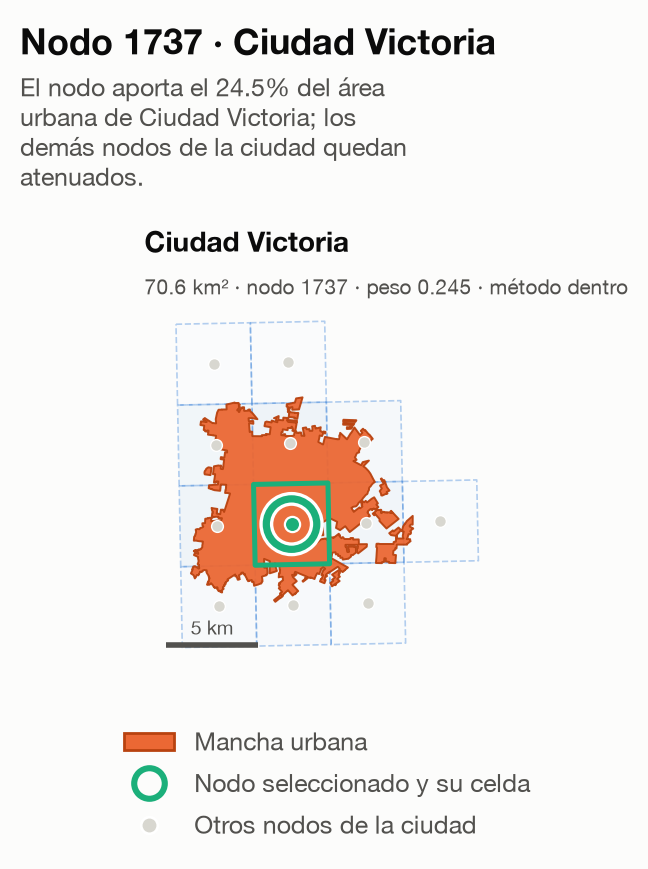

In [5]:
from urbano.mapas import nodo as N
from IPython.display import Image, display

ruta = N.mapa_nodo(1737)
print(ruta)
display(Image(filename=ruta, width=460))

/Users/esteban/Documents/ACADEMICO/DSI/Radiacion_Solar/Results/Tamaulipas/urbano/panel_nodos_seleccionados.png


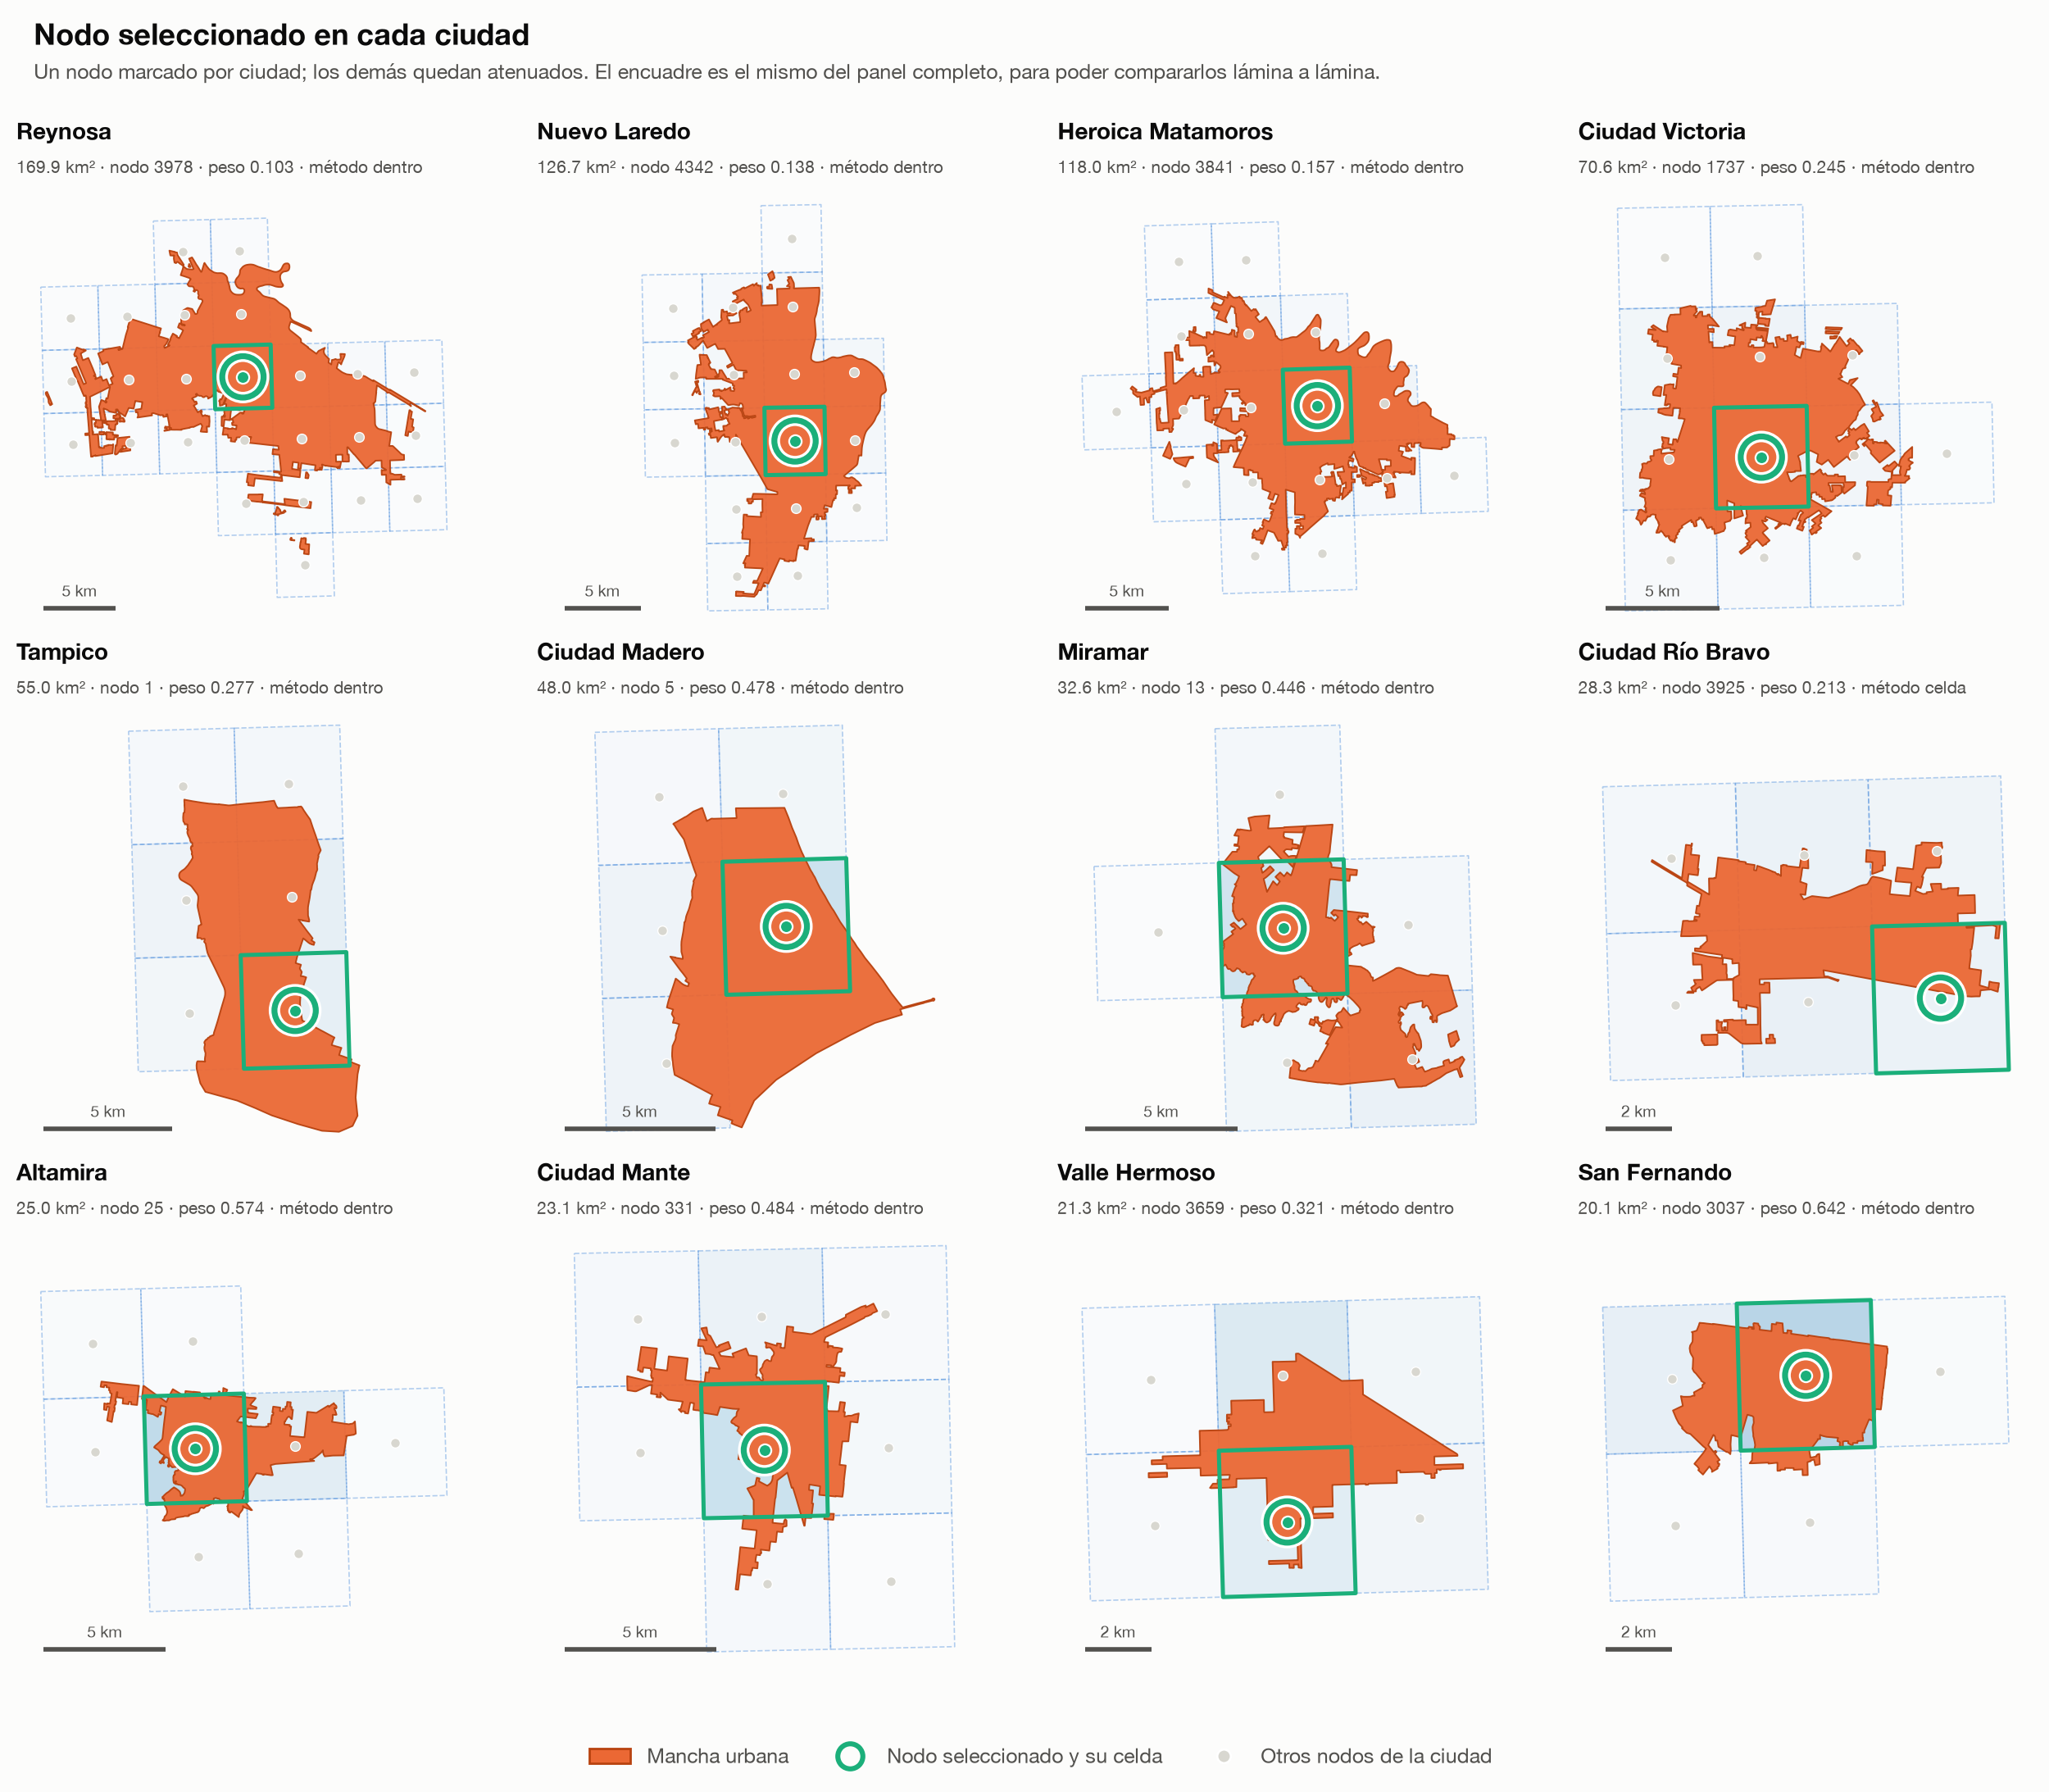

In [6]:
# Los 12 a la vez, en la misma rejilla del panel de ciudades.
ruta_panel = N.panel_nodos(base=False)
print(ruta_panel)
display(Image(filename=ruta_panel, width=1000))

### Los datos de un nodo

Exactamente la misma llamada de siempre, cambiando `ciudad=` por `nodo=`.

In [7]:
# Temperatura del nodo 1737 (Ciudad Victoria), junio 2024.
d = Q.serie(["temperature"], nodo=1737,
            desde="2024-06-01", hasta="2024-06-30", frecuencia="dia")
d.head()

,cvegeo,ciudad,municipio,calidad,fecha_local,temperature_media,temperature_min,temperature_max,n_horas
0,nodo-1737,nodo 1737,Victoria,nodo,2024-06-01,33.487500,25.900000,42.400002,24
1,nodo-1737,nodo 1737,Victoria,nodo,2024-06-02,33.845833,26.500000,43.099998,24
2,nodo-1737,nodo 1737,Victoria,nodo,2024-06-03,35.770833,28.299999,45.799999,24
3,nodo-1737,nodo 1737,Victoria,nodo,2024-06-04,36.125000,28.500000,45.099998,24
4,nodo-1737,nodo 1737,Victoria,nodo,2024-06-05,36.016667,28.200001,45.700001,24


In [8]:
print("media del mes :", round(d["temperature_media"].mean(), 2), "°C")
print("mínimo absoluto:", round(d["temperature_min"].min(), 2), "°C")
print("máximo absoluto:", round(d["temperature_max"].max(), 2), "°C")

media del mes : 30.77 °C
mínimo absoluto: 23.6 °C
máximo absoluto: 45.8 °C


### Lo mismo para cualquier variable

In [ ]:
VARS = ["temperature", "relative_humidity", "wind_speed", "ghi"]
d = Q.serie(VARS, nodo=1737, desde="2024-01-01", hasta="2024-12-31",
            frecuencia="dia")

pd.DataFrame({
    "media":  [d[f"{v}_media"].mean() for v in VARS],
    "mínimo": [d[f"{v}_min"].min() for v in VARS],
    "máximo": [d[f"{v}_max"].max() for v in VARS],
    "unidad": [V.CATALOGO[v].unidad for v in VARS],
    "altura": [V.CATALOGO[v].altura for v in VARS],
}, index=VARS).round(2)

### Los 12 nodos, comparados

In [ ]:
sel = Q.nodos_interes()
d12 = Q.serie(VARS, nodo=sel["nodo_id"].tolist(),
              desde="2024-01-01", hasta="2024-12-31", frecuencia="dia")

r = d12.groupby("ciudad").agg(
    t_media=("temperature_media", "mean"),
    t_min=("temperature_min", "min"),
    t_max=("temperature_max", "max"),
    hr_media=("relative_humidity_media", "mean"),
    viento_medio=("wind_speed_media", "mean"),
    ghi_medio=("ghi_media", "mean"))
r.insert(0, "ubicacion",
         r.index.map(dict(zip("nodo " + sel["nodo_id"].astype(str), sel["ciudad"]))))
r.round(2).sort_values("t_media", ascending=False)

### Los 12 nodos: temperatura y humedad relativa

Celda lista para usar. Cambia `DESDE`, `HASTA` y `VARIABLES` y vuelve a
ejecutarla; no depende de nada de las celdas anteriores salvo el arranque.

In [11]:
DESDE, HASTA = "2024-01-01", "2024-12-31"
VARIABLES = ["temperature", "relative_humidity"]

sel12 = Q.nodos_interes()

# Serie diaria de los 12 nodos: media, mínimo y máximo de cada variable por día.
diario12 = Q.serie(VARIABLES, nodo=sel12["nodo_id"].tolist(),
                   desde=DESDE, hasta=HASTA, frecuencia="dia")

# Igual que con los 43: el id sale de la etiqueta, y el resto de `sel12`.
diario12["nodo_id"] = diario12["ciudad"].str.removeprefix("nodo ").astype(int)
etiquetas12 = (sel12.set_index("nodo_id")[["cve_mun", "municipio", "ciudad"]]
               .rename(columns={"ciudad": "ubicacion"}))
diario12 = (diario12.drop(columns=["cve_mun", "municipio"], errors="ignore")
                    .join(etiquetas12, on="nodo_id"))
cols = ["cve_mun", "municipio", "ubicacion", "nodo_id", "fecha_local"]
diario12 = diario12[cols + [c for c in diario12.columns if c not in cols]]

print(f"{len(diario12):,} filas · {diario12['nodo_id'].nunique()} nodos · "
      f"{DESDE} → {HASTA}")
diario12.head()

21,924 filas · 12 nodos · 2020-01-01 → 2024-12-31


,ubicacion,nodo_id,cvegeo,ciudad,municipio,calidad,fecha_local,temperature_media,temperature_min,temperature_max,relative_humidity_media,relative_humidity_min,relative_humidity_max,n_horas
0,Tampico,1,nodo-1,nodo 1,Tampico,nodo,2020-01-01,21.333333,19.100000,24.200001,92.567500,81.290001,99.339996,24
1,Tampico,1,nodo-1,nodo 1,Tampico,nodo,2020-01-02,23.162500,20.299999,27.000000,92.147500,76.209999,100.000000,24
2,Tampico,1,nodo-1,nodo 1,Tampico,nodo,2020-01-03,21.900000,18.100000,25.100000,73.632083,45.810001,100.000000,24
3,Tampico,1,nodo-1,nodo 1,Tampico,nodo,2020-01-04,17.725000,14.700000,21.799999,61.621250,42.939999,77.349998,24
4,Tampico,1,nodo-1,nodo 1,Tampico,nodo,2020-01-05,15.829167,12.500000,19.200001,70.014167,48.400002,88.360001,24


In [12]:
# Resumen por nodo: media de las medias diarias, y los extremos absolutos.
resumen12 = (diario12.groupby(["cve_mun", "ubicacion", "nodo_id"])
             .agg(**{f"{v}_{etq}": (f"{v}_{col}", agg)
                     for v in VARIABLES
                     for etq, col, agg in [("media", "media", "mean"),
                                           ("min", "min", "min"),
                                           ("max", "max", "max")]})
             .round(2)
             .sort_values("temperature_media", ascending=False)
             .reset_index())
resumen12

,ubicacion,nodo_id,temperature_media,temperature_min,temperature_max,relative_humidity_media,relative_humidity_min,relative_humidity_max
0,Ciudad Mante,331,26.51,4.3,49.6,62.83,2.27,100.00
1,Ciudad Victoria,1737,25.63,1.1,48.0,56.85,3.90,96.23
2,Ciudad Madero,5,25.55,6.5,38.2,80.12,19.49,100.00
3,Tampico,1,25.47,5.6,39.9,79.58,16.59,100.00
4,Miramar,13,25.41,4.4,40.9,78.80,13.97,100.00
5,Altamira,25,25.35,3.8,41.7,78.47,12.67,100.00
6,Valle Hermoso,3659,24.83,-2.9,41.8,74.56,9.82,100.00
7,Heroica Matamoros,3841,24.79,-3.0,41.0,75.82,11.51,100.00
8,Ciudad Río Bravo,3925,24.74,-5.2,44.9,71.34,6.27,100.00
9,Reynosa,3978,24.71,-5.3,45.1,70.98,6.09,100.00


In [ ]:
# Guardarlo, si hace falta.
import os
os.makedirs(C.DIR_CLIMA, exist_ok=True)
ruta_diario = os.path.join(C.DIR_CLIMA, "diario_nodos_interes.csv")
ruta_resumen = os.path.join(C.DIR_CLIMA, "resumen_nodos_interes.csv")
diario12.to_csv(ruta_diario, index=False)
resumen12.to_csv(ruta_resumen, index=False)
for r in (ruta_diario, ruta_resumen):
    print(f"{os.path.getsize(r)/1e6:6.2f} MB  {r}")

  3.63 MB  /Users/esteban/Documents/ACADEMICO/DSI/Radiacion_Solar/Data/Tamaulipas/urbano/clima/diario_nodos_interes.csv
  0.00 MB  /Users/esteban/Documents/ACADEMICO/DSI/Radiacion_Solar/Data/Tamaulipas/urbano/clima/resumen_nodos_interes.csv


In [15]:
# Solo la serie horaria, si prefieres el dato sin agregar por día.
horaria12 = Q.serie(VARIABLES, nodo=sel12["nodo_id"].tolist(),
                    desde=DESDE, hasta=HASTA)
horaria12["nodo_id"] = horaria12["ciudad"].str.removeprefix("nodo ").astype(int)
horaria12 = horaria12.join(etiquetas12[["ubicacion"]], on="nodo_id")
print(f"{len(horaria12):,} filas")
horaria12[["cve_mun", "municipio", "ubicacion", "nodo_id", "datetime_utc",
           "hora_local", *VARIABLES]].head()

Archivo guardado en: /Users/esteban/Documents/ACADEMICO/DSI/Radiacion_Solar/Data/Tamaulipas/urbano/clima/serie_horaria_12_nodos.csv
526,104 filas


,ubicacion,ciudad,municipio,datetime_utc,hora_local,temperature,relative_humidity
0,Tampico,nodo 1,Tampico,2020-01-01 06:00:00+00:00,2020-01-01 00:00:00,19.799999,96.480003
1,Tampico,nodo 1,Tampico,2020-01-01 07:00:00+00:00,2020-01-01 01:00:00,19.700001,96.690002
2,Tampico,nodo 1,Tampico,2020-01-01 08:00:00+00:00,2020-01-01 02:00:00,19.500000,97.430000
3,Tampico,nodo 1,Tampico,2020-01-01 09:00:00+00:00,2020-01-01 03:00:00,19.400000,97.519997
4,Tampico,nodo 1,Tampico,2020-01-01 10:00:00+00:00,2020-01-01 04:00:00,19.200001,98.070000


---
### Los 43 nodos de las cabeceras municipales

Un nodo señalado por cada una de las 43 cabeceras, en
`Data/Tamaulipas/urbano/nodos_interes_municipios.csv`. Se identificaron igual
que los 12: detectando los círculos por color sobre las páginas del catálogo y
proyectándolos a coordenadas del mapa (nodo elegido a ≤0.35 km del centro del
círculo, siguiente a ≥4.2 km).

**Gómez Farías va aparte.** Sus páginas se marcaron antes de corregir la
cabecera, así que el círculo rojo caía sobre *Loma Alta*; el nodo bueno —el
**784**, en la cabecera de verdad— salió del recorte marcado en verde.

Mapas: `python -m urbano.mapas.nodo --municipios` → 4 páginas × 2 modalidades en
`Results/Tamaulipas/urbano/catalogo/nodos_de_interes/`.

In [3]:
from urbano.mapas import nodo as N

sel43 = N.nodos_interes_municipios()
print(f"{len(sel43)} cabeceras · {sel43['nodo_id'].nunique()} nodos distintos")
sel43.head(43)

43 cabeceras · 43 nodos distintos


,cve_mun,municipio,cvegeo,ciudad,nodo_id,latitude,longitude,msnm,metodo,peso,calidad,area_km2
0,001,Abasolo,280010001,Abasolo,2120,24.05,-98.38,55.0,celda,0.943752,baja,5.861689
1,002,Aldama,280020001,Aldama,637,22.93,-98.06,142.0,celda,0.694106,baja,6.277993
2,003,Altamira,280030001,Altamira,25,22.41,-97.94,6.0,dentro,0.573937,media,25.026891
3,004,Antiguo Morelos,280040001,Antiguo Morelos,154,22.57,-99.10,193.0,celda,0.495785,baja,2.530162
4,005,Burgos,280050001,Burgos,3094,24.93,-98.82,198.0,celda,0.402801,baja,1.878181
5,006,Bustamante,280060001,Bustamante,1343,23.45,-99.78,2140.0,celda,0.340308,baja,1.232583
6,007,Camargo,280070001,Ciudad Camargo,4118,26.33,-98.82,49.0,celda,0.678652,baja,5.914835
7,008,Casas,280080001,Casas,1747,23.73,-98.74,157.0,dentro,1.000000,media,0.900316
8,009,Ciudad Madero,280090001,Ciudad Madero,5,22.29,-97.82,6.0,dentro,0.477606,media,48.024578
9,010,Cruillas,280100001,Cruillas,2953,24.77,-98.54,213.0,celda,0.773472,baja,1.153808


#### Los datos de los 43, juntos

Misma llamada y mismos filtros que con los 12: cambia la lista de nodos.

In [4]:
DESDE, HASTA = "2020-01-01", "2024-12-31"
VARIABLES = ["temperature", "relative_humidity"]

diario43 = Q.serie(VARIABLES, nodo=sel43["nodo_id"].tolist(),
                   desde=DESDE, hasta=HASTA, frecuencia="dia")

# La unidad llega etiquetada como "nodo <id>": de ahí se recupera el id.
diario43["nodo_id"] = diario43["ciudad"].str.removeprefix("nodo ").astype(int)

# Municipio, clave y cabecera se toman de `sel43`, que es la tabla de selección
# y la fuente de verdad de esta celda. Se descartan antes las columnas
# equivalentes que ya traiga la serie, para no depender de su composición
# exacta ni chocar al reinsertarlas.
etiquetas = (sel43.set_index("nodo_id")[["cve_mun", "municipio", "ciudad"]]
             .rename(columns={"ciudad": "cabecera"}))
diario43 = (diario43.drop(columns=["cve_mun", "municipio"], errors="ignore")
                    .join(etiquetas, on="nodo_id"))

# `cve_mun` al frente: es la clave con la que se cruza con cualquier otra
# fuente municipal.
cols = ["cve_mun", "municipio", "cabecera", "nodo_id", "fecha_local"]
diario43 = diario43[cols + [c for c in diario43.columns if c not in cols]]
diario43 = diario43.sort_values(["cve_mun", "fecha_local"]).reset_index(drop=True)

print(f"{len(diario43):,} filas · {diario43['cve_mun'].nunique()} municipios · "
      f"{DESDE} → {HASTA}")
diario43.head()

78,561 filas · 43 municipios · 2020-01-01 → 2024-12-31


,cve_mun,municipio,cabecera,nodo_id,fecha_local,cvegeo,ciudad,calidad,temperature_media,temperature_min,temperature_max,relative_humidity_media,relative_humidity_min,relative_humidity_max,n_horas
0,001,Abasolo,Abasolo,2120,2020-01-01,nodo-2120,nodo 2120,nodo,19.437500,15.8,25.299999,87.196250,66.230003,99.059998,24
1,001,Abasolo,Abasolo,2120,2020-01-02,nodo-2120,nodo 2120,nodo,20.966667,15.2,28.900000,81.643749,55.970001,95.830002,24
2,001,Abasolo,Abasolo,2120,2020-01-03,nodo-2120,nodo 2120,nodo,19.212500,13.3,25.600000,51.152500,27.080000,96.370003,24
3,001,Abasolo,Abasolo,2120,2020-01-04,nodo-2120,nodo 2120,nodo,15.504167,10.2,23.700001,49.157083,22.870001,71.559998,24
4,001,Abasolo,Abasolo,2120,2020-01-05,nodo-2120,nodo 2120,nodo,15.079167,8.9,23.700001,56.573333,26.190001,80.400002,24


In [5]:
# Resumen por municipio: media de las medias diarias y extremos absolutos.
resumen43 = (diario43.groupby(["cve_mun", "municipio", "cabecera", "nodo_id"])
             .agg(**{f"{v}_{etq}": (f"{v}_{col}", agg)
                     for v in VARIABLES
                     for etq, col, agg in [("media", "media", "mean"),
                                           ("min", "min", "min"),
                                           ("max", "max", "max")]})
             .round(2).reset_index())
resumen43

,cve_mun,municipio,cabecera,nodo_id,temperature_media,temperature_min,temperature_max,relative_humidity_media,relative_humidity_min,relative_humidity_max
0,001,Abasolo,Abasolo,2120,25.20,-1.7,47.3,70.07,6.08,100.00
1,002,Aldama,Aldama,637,24.94,-0.5,45.6,75.63,5.99,100.00
2,003,Altamira,Altamira,25,25.35,3.8,41.7,78.47,12.67,100.00
3,004,Antiguo Morelos,Antiguo Morelos,154,26.16,4.6,49.5,62.64,2.25,100.00
4,005,Burgos,Burgos,3094,24.79,-4.5,46.3,65.94,4.91,100.00
5,006,Bustamante,Bustamante,1343,17.45,-1.9,39.1,68.31,2.44,100.00
6,007,Camargo,Ciudad Camargo,4118,24.99,-5.3,46.8,65.62,5.33,100.00
7,008,Casas,Casas,1747,25.08,-1.3,48.0,65.97,5.16,100.00
8,009,Ciudad Madero,Ciudad Madero,5,25.55,6.5,38.2,80.12,19.49,100.00
9,010,Cruillas,Cruillas,2953,24.33,-4.0,45.5,69.46,5.41,100.00


In [6]:
# Los extremos del estado, sobre cabeceras municipales.
print("— más cálidas —")
display(resumen43.nlargest(5, "temperature_media")[
    ["cve_mun", "municipio", "temperature_media", "temperature_max"]])
print("— más frías —")
display(resumen43.nsmallest(5, "temperature_media")[
    ["cve_mun", "municipio", "temperature_media", "temperature_min"]])

— más cálidas —


,cve_mun,municipio,temperature_media,temperature_max
20,021,El Mante,26.51,49.6
28,029,Ocampo,26.31,50.3
3,004,Antiguo Morelos,26.16,49.5
27,028,Nuevo Morelos,26.11,49.9
10,011,Gómez Farías,26.01,49.6


— más frías —


,cve_mun,municipio,temperature_media,temperature_min
25,026,Miquihuana,16.61,-3.4
5,006,Bustamante,17.45,-1.9
30,031,Palmillas,20.60,-0.2
38,039,Tula,21.18,1.2
35,036,San Nicolás,21.84,-6.2


In [7]:
# Guardarlo. Los CSV llevan la clave municipal `cve_mun` como primera columna.
import os
os.makedirs(C.DIR_CLIMA, exist_ok=True)
r_diario = os.path.join(C.DIR_CLIMA, "diario_nodos_municipios.csv")
r_resumen = os.path.join(C.DIR_CLIMA, "resumen_nodos_municipios.csv")
diario43.to_csv(r_diario, index=False)
resumen43.to_csv(r_resumen, index=False)
for r in (r_diario, r_resumen):
    print(f"{os.path.getsize(r)/1e6:6.2f} MB  {r}")

 13.45 MB  /Users/esteban/Documents/ACADEMICO/DSI/Radiacion_Solar/Data/Tamaulipas/urbano/clima/diario_nodos_municipios.csv
  0.00 MB  /Users/esteban/Documents/ACADEMICO/DSI/Radiacion_Solar/Data/Tamaulipas/urbano/clima/resumen_nodos_municipios.csv


In [8]:
# Serie horaria de los 43, si hace falta el dato sin agregar.
horaria43 = Q.serie(VARIABLES, nodo=sel43["nodo_id"].tolist(),
                    desde=DESDE, hasta=HASTA)

# Guardar la serie horaria completa, que es la más pesada de todas.
r_horaria = os.path.join(C.DIR_CLIMA, "horaria_nodos_municipios.csv")
horaria43.to_csv(r_horaria, index=False)
print(f"{len(horaria43):,} filas")
horaria43[["cvegeo", "municipio", "cve_mun", "datetime_utc", "hora_local",
           *VARIABLES]].head()

1,885,206 filas


,cvegeo,municipio,cve_mun,datetime_utc,hora_local,temperature,relative_humidity
0,nodo-1,Tampico,038,2020-01-01 06:00:00+00:00,2020-01-01 00:00:00,19.799999,96.480003
1,nodo-1,Tampico,038,2020-01-01 07:00:00+00:00,2020-01-01 01:00:00,19.700001,96.690002
2,nodo-1,Tampico,038,2020-01-01 08:00:00+00:00,2020-01-01 02:00:00,19.500000,97.430000
3,nodo-1,Tampico,038,2020-01-01 09:00:00+00:00,2020-01-01 03:00:00,19.400000,97.519997
4,nodo-1,Tampico,038,2020-01-01 10:00:00+00:00,2020-01-01 04:00:00,19.200001,98.070000


In [ ]:
# Los mapas del catálogo, con el nodo marcado en verde.
from IPython.display import Image, display

rutas43 = N.catalogo_municipios(con_base=False)
for r in rutas43:
    print(os.path.basename(r))
    display(Image(filename=r, width=1000))

### Nodo vs. ciudad: ¿cuánto cambia?

El promedio de ciudad y el nodo suelto **no** dan lo mismo, y esa es justamente
la razón de que existan los dos. En una ciudad de cobertura `alta` el promedio
suaviza; en una de cobertura `baja` casi no hay diferencia, porque el "promedio"
ya era prácticamente un solo nodo.

In [ ]:
comparacion = []
for _, s in Q.nodos_interes().iterrows():
    n = Q.serie(["temperature"], nodo=int(s["nodo_id"]),
                desde="2024-01-01", hasta="2024-12-31")
    c = Q.serie(["temperature"], ciudad=s["cvegeo"],
                desde="2024-01-01", hasta="2024-12-31")
    dif = n["temperature"].to_numpy() - c["temperature"].to_numpy()
    comparacion.append({
        "ciudad": s["ciudad"], "nodo": int(s["nodo_id"]),
        "peso_del_nodo": s["peso"],
        "dif_media": dif.mean(), "dif_max_abs": abs(dif).max()})
pd.DataFrame(comparacion).sort_values("dif_max_abs", ascending=False).round(3)

### Cualquier nodo, no solo los señalados

`nodo=` acepta cualquiera de los 4384 de la malla, tenga ciudad o no. El
municipio (y con él el huso horario) se resuelve por geometría.

In [ ]:
Q.pesos_nodo([1737, 3978, 4342])

In [ ]:
# Un nodo cualquiera sin ciudad: la serie funciona igual...
h = Q.serie(["temperature"], nodo=2000, desde="2024-06-01", hasta="2024-06-02")
print(h[["ciudad", "municipio", "hora_local", "temperature"]].head(3)
        .to_string(index=False))

# ...pero no tiene mapa de ciudad, porque no toca ninguna mancha urbana.
from urbano.nodos import asignacion as A
from urbano.data import manchas as M
try:
    N.ciudad_del_nodo(2000, A.asignar(M.manchas_urbanas(), A.cargar_nodos()))
except ValueError as e:
    print("\n·", e)

---
## Paso 10 · Generar archivos desde la terminal

Para no recalcular en cada sesión.

```bash
# las 12 localidades mayores (por omisión)
python -m urbano.clima.construir_clima

# por ámbito
python -m urbano.clima.construir_clima --ambito cabeceras
python -m urbano.clima.construir_clima --ambito otras
python -m urbano.clima.construir_clima --ambito localidades
python -m urbano.clima.construir_clima --ambito conglomerados
python -m urbano.clima.construir_clima --ambito global
python -m urbano.clima.construir_clima --todos-los-ambitos

# variantes
python -m urbano.clima.construir_clima --simple            # sin ponderar
python -m urbano.clima.construir_clima --anios 2023 2024
python -m urbano.clima.construir_clima --variables temperature relative_humidity
python -m urbano.clima.construir_clima --horario-csv       # además del parquet
```

Cada ámbito escribe `diario_<ambito>.csv` y `horario_<ambito>.parquet`, así que
no se pisan entre sí (`--simple` añade su propio sufijo).

**Tamaño:** un juego completo son ~395 MB. `.gitignore` versiona solo
`diario_ciudades.csv` y `diario_global.csv`; lo demás se regenera.

In [ ]:
# Equivalente en Python de `--ambito global`, por si lo prefieres en el notebook.
g = Q.serie(["temperature"], ambito="global",
            desde="2024-01-01", hasta="2024-12-31", frecuencia="dia")
print(g.shape)
g.head(3)

---
## Resumen de la API

```python
from urbano.clima import consulta as Q
from urbano.clima import variables as V

Q.catalogo()                     # DataFrame con las 63 localidades
Q.resolver("victoria")           # "280410001"
Q.AMBITOS                        # los cinco ámbitos
Q.pesos(ambito)                  # tabla nodo↔unidad con pesos
Q.serie(variables,               # lista de nombres de V.CATALOGO
        ciudad=None,             # clave / nombre / lista de ellos
        ambito="localidades",    # se ignora si se pasa `ciudad`
        desde=None, hasta=None,  # inclusivos, hora local
        frecuencia="hora",       # "hora" | "dia"
        ponderar=True)           # False = promedio simple

V.CATALOGO       # dict variable -> metadatos (unidad, altura, tipo)
V.tabla()        # el catálogo como DataFrame
V.POR_OMISION    # las 10 variables por omisión
```